<a href="https://colab.research.google.com/github/vahagngrigoryan2006/flyrank-internship-ml/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vahagngrigoryan2006/flyrank-internship-ml/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

My lane (lane 1) focuses on interpreting which signals have connection to the engagement, clicks, performance, etc. For that I have chosen a target `is_declining` in previous notebooks. I want to understand which predictors are associated with it. So my model needs to be interpretable. So I am planning to use logistic regression, or a shallow decision tree. Please build both and I will see which one is more interpretable.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
import json as _json
import numpy as np
import pandas as pd
import duckdb

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text

print("Imports ready.")


Imports ready.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

I will group by client. When a single client has a content in both train and test sets, it is a leak of information. My split does not need to be time-aware, as I only cover the April-May period.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")
assert HF_TOKEN, "Set HF_TOKEN as a Colab secret before continuing."

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN \'{HF_TOKEN}\')")

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
DIM_CONTENT    = f"read_parquet(\'{WAREHOUSE}/dim_content.parquet\')"
FACT_APRIL_MAY = (
    f"read_parquet([\'{WAREHOUSE}/fact_content_daily_performance/month=2026-03/*.parquet\', "
    f"\'{WAREHOUSE}/fact_content_daily_performance/month=2026-04/*.parquet\', "
    f"\'{WAREHOUSE}/fact_content_daily_performance/month=2026-05/*.parquet\'])"
)

# ---- Same window as w03/w04: as-of 2026-05-31, decision moment 2026-05-01 ----
# ---- Same query shape as w03_feature_leakage_check.ipynb section 1 (prev_30 GSC + GA4 + scroll) ----
features = con.sql(f"""
    WITH bounds AS (
        SELECT DATE \'2026-05-31\' AS as_of_date
    ),
    per_item AS (
        SELECT f.client_hash_id, f.content_hash_id,
               MIN(f.report_date) AS first_seen,
               SUM(CASE WHEN f.report_date >= b.as_of_date - INTERVAL 30 DAY
                        THEN f.gsc_impressions ELSE 0 END) AS last_30_impressions,
               SUM(CASE WHEN f.report_date <  b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.gsc_impressions ELSE 0 END) AS prev_30_impressions,
               AVG(CASE WHEN f.report_date <  b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.gsc_avg_position END)       AS prev_30_avg_position,
               SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.gsc_clicks ELSE 0 END) AS prev_30_clicks,
               CASE
                   WHEN SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                                 THEN f.gsc_impressions ELSE 0 END) > 0
                   THEN SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                                 THEN f.gsc_clicks ELSE 0 END)
                        / SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                                 THEN f.gsc_impressions ELSE 0 END)
               END AS prev_30_ctr,
               SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.ga4_sessions ELSE 0 END) AS prev_30_sessions,
               SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.ga4_engaged_sessions ELSE 0 END) AS prev_30_engaged_sessions,
               SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.scroll_events ELSE 0 END) AS prev_30_scroll_events,



              SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.gsc_avg_position * f.gsc_impressions ELSE 0 END) /
                  NULLIF(SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.gsc_impressions ELSE 0 END), 0
                        ) AS weighted_position,

              CASE WHEN SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.ga4_sessions ELSE 0 END) > 0
                  THEN SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.ga4_engaged_sessions ELSE 0 END) /
                  SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                        THEN f.ga4_sessions ELSE 0 END) END AS engagement_rate

        FROM {FACT_APRIL_MAY} f, bounds b
        GROUP BY 1, 2
    )
    FROM per_item p
    JOIN {DIM_CONTENT} d USING (content_hash_id)
    WHERE p.first_seen <= DATE \'2026-05-31\' - INTERVAL 60 DAY   -- guard (a): full prev_30 history
      AND p.prev_30_impressions >= 100                             -- guard (b): activity floor
""").df()

decision_moment = pd.Timestamp("2026-05-01")
features["content_created_date"] = pd.to_datetime(features["content_created_date"])
features["content_updated_date"] = pd.to_datetime(features["content_updated_date"])
features["content_age_days_at_decision"] = (decision_moment - features["content_created_date"]).dt.days
features["days_since_last_update_at_decision"] = (decision_moment - features["content_updated_date"]).dt.days

features["keyword_created_date"] = pd.to_datetime(features["keyword_created_date"])
features["keyword_age_days_at_decision"] = (decision_moment - features["keyword_created_date"]).dt.days

features = features[features["days_since_last_update_at_decision"] > 0]   # guard (c)

# is_declining -- the label. Not part of w03\'s feature set (it can\'t be: last_30_impressions is
# banned from the predictors), computed fresh here the same way every notebook so far has.
features["impressions_pct_change"] = (
    (features["last_30_impressions"] - features["prev_30_impressions"]) / features["prev_30_impressions"]
)
features["is_declining"] = (features["impressions_pct_change"] < -0.20).astype(int)

print(f"Feature frame: {len(features):,} content items surviving all three guards.")
print(f"is_declining rate: {features['is_declining'].mean():.3f}")

# ==================================================================================
# EXACT feature set from w03_feature_leakage_check.ipynb, section 2 (23 predictors,
# same NA handling) -- copied here on purpose so this notebook stays self-contained.
# ==================================================================================
selected_features = [
    "prev_30_impressions", "prev_30_avg_position", "prev_30_clicks", "prev_30_ctr",
    "prev_30_sessions", "prev_30_engaged_sessions", "prev_30_scroll_events",
    "content_age_days_at_decision", "days_since_last_update_at_decision",
    "keyword_char_count", "keyword_token_count", "content_type",
    "search_volume", "competition", "cpc", "keyword_age_days_at_decision",
    "main_intent", "backlinks", "category_count", "char_count", "word_count"
]

df = features[selected_features].copy()

bins = [-np.inf, 1000, 2000, 3500, np.inf]
labels = ["<1000", "1000-2000", "2000-3500", "3500+"]
df["word_count_tier"] = pd.cut(df["word_count"], bins=bins, labels=labels, right=False).astype("object").fillna("NA")

bins = [-np.inf, 8000, 15000, 25000, np.inf]
labels = ["<8000", "8000-15000", "15000-25000", "25000+"]
df["char_count_tier"] = pd.cut(df["char_count"], bins=bins, labels=labels, right=False).astype("object").fillna("NA")

df = df.drop(columns=["word_count", "char_count"])

df["no_keyword_data"] = df["competition"].isna().astype(int)
df["search_volume"] = df["search_volume"].fillna(0)
df["competition"] = df["competition"].fillna(0)
df["cpc"] = df["cpc"].fillna(0)
df["keyword_age_days_at_decision"] = df["keyword_age_days_at_decision"].fillna(-30)
df["main_intent"] = df["main_intent"].fillna("NA")
df["backlinks_na"] = df["backlinks"].isna().astype(int)
df["backlinks"] = df["backlinks"].fillna(0)


print(f"\nFeature matrix: {df.shape[0]:,} rows x {df.shape[1]} columns (should be 23, matching w03).")
assert df.isna().sum().sum() == 0, "Unexpected NAs remain -- w03\'s handling should leave none."

y = features.loc[df.index, "is_declining"]
groups = features.loc[df.index, "client_hash_id"]

# ---- Client-grouped split (per the reasoning above): no client in both train and test ----
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups))

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])
print(f"\nTrain: {len(train_idx):,} rows, {len(train_clients)} clients")
print(f"Test:  {len(test_idx):,} rows, {len(test_clients)} clients")
print(f"Client overlap between train and test: {len(train_clients & test_clients)}")
assert len(train_clients & test_clients) == 0, "Leakage: a client appears in both train and test."


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature frame: 18,918 content items surviving all three guards.
is_declining rate: 0.543

Feature matrix: 18,918 rows x 23 columns (should be 23, matching w03).

Train: 11,657 rows, 20 clients
Test:  7,261 rows, 7 clients
Client overlap between train and test: 0


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Comparing against w04_baseline_score.ipynb's live rule (CTR_BELOW_POSITION_PEERS, scored by impressions x ctr_gap), recomputed below on this exact row population and then restricted to this notebook's held-out test split -- not the full 18,918-row set it was originally evaluated on, so this is a like-for-like comparison, not a rerun of the old number. Metric: precision@10 / @50 / @100 against is_declining, plus the test set's own base rate -- same metric shape w04_baseline_score.ipynb already established. Both models are also printed in a directly readable form (the tree's text, the regression's coefficients), since section 1's whole point was picking methods you could read -- that's not the error analysis in section 4, just confirming these two are actually as readable as planned.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

numeric_cols = ["prev_30_impressions", "prev_30_avg_position", "prev_30_clicks", "prev_30_ctr",
                "prev_30_sessions", "prev_30_engaged_sessions", "prev_30_scroll_events",
                "content_age_days_at_decision", "days_since_last_update_at_decision",
                "keyword_char_count", "keyword_token_count", "search_volume", "competition", "cpc",
                "keyword_age_days_at_decision", "backlinks", "category_count",
                "no_keyword_data", "backlinks_na"]
categorical_cols = ["content_type", "main_intent", "word_count_tier", "char_count_tier"]
assert set(numeric_cols + categorical_cols) == set(df.columns), "Feature list drifted from the built df."

X_train, X_test = df.iloc[train_idx], df.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Logistic Regression: scaled numeric + one-hot categorical -- coefficients are directly readable
lr_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

# Decision Tree: shallow ON PURPOSE (max_depth=3) so it stays print-and-read; no scaling needed
tree_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])),
    ("clf", DecisionTreeClassifier(max_depth=3, min_samples_leaf=200, random_state=42)),
])

lr_pipe.fit(X_train, y_train)
tree_pipe.fit(X_train, y_train)
print("Both models fit on the train split (random_state=42, fixed for reproducibility).")

# ---- Recompute the Week-4 baseline (CTR_BELOW_POSITION_PEERS), same row population ----
baseline_df = features.loc[df.index].copy()

position_bins = [0, 3, 10, 20, 50, np.inf]
position_labels = ["top_3", "page_1", "striking_distance", "page_2_3", "deep"]
baseline_df["position_tier"] = pd.cut(baseline_df["prev_30_avg_position"], bins=position_bins, labels=position_labels)

enough_impressions = baseline_df["prev_30_impressions"] >= 500
not_brand_new       = baseline_df["content_age_days_at_decision"] >= 90
not_in_cooldown      = baseline_df["days_since_last_update_at_decision"] >= 60
eligible = enough_impressions & not_brand_new & not_in_cooldown

# The only thing this rule "learns" from data is the tier-mean CTR benchmark -- and per the
# split design in section 2, that has to come from TRAIN rows only, exactly like the models below.
# Everything else (the three eligibility gates, the `== 0` condition) is a fixed threshold, not a
# fit statistic, so it needs no train/test distinction.
train_eligible_rows = baseline_df.iloc[train_idx][eligible.iloc[train_idx]]
tier_means = train_eligible_rows.groupby("position_tier", observed=True)["prev_30_ctr"].mean()
print("Tier-mean CTR learned from TRAIN-eligible rows only:")
print(tier_means.round(6))

# .map() on a Categorical column silently returns a Categorical dtype -- .to_dict() + astype(float)
# avoids that trap.
baseline_df["expected_ctr_for_tier"] = baseline_df["position_tier"].map(tier_means.to_dict()).astype(float)
baseline_df["ctr_gap"] = (baseline_df["expected_ctr_for_tier"] - baseline_df["prev_30_ctr"]).fillna(0)

far_below_peers = baseline_df["prev_30_ctr"] == 0
flagged = eligible & far_below_peers
baseline_df["score"] = np.where(flagged, baseline_df["prev_30_impressions"] * baseline_df["ctr_gap"], 0.0)
print(f"\nBaseline built on {len(baseline_df):,} rows; only the TEST split ({len(test_idx):,} rows) "
      f"is used for its precision@K below, same as the models.")

# ---- The comparison table (non-negotiable, per the skill): same split, same metric, base rate ----
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return labels.values[order][:k].mean()

lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
tree_proba = tree_pipe.predict_proba(X_test)[:, 1]
baseline_scores = baseline_df["score"].iloc[test_idx].values

base_rate_test = y_test.mean()
rows = []
for k in [10, 50, 100]:
    rows.append({"model": "baseline_CTR_BELOW_POSITION_PEERS", "k": k, "precision_at_k": precision_at_k(baseline_scores, y_test, k)})
    rows.append({"model": "logistic_regression",               "k": k, "precision_at_k": precision_at_k(lr_proba, y_test, k)})
    rows.append({"model": "decision_tree_depth3",              "k": k, "precision_at_k": precision_at_k(tree_proba, y_test, k)})

comparison = pd.DataFrame(rows)
print(f"\nTest set: {len(test_idx):,} rows, base rate (is_declining) = {base_rate_test:.3f}")
comparison_table = comparison.pivot(index="model", columns="k", values="precision_at_k").round(3)
comparison_table["base_rate_test"] = round(base_rate_test, 3)
comparison_table

Both models fit on the train split (random_state=42, fixed for reproducibility).
Tier-mean CTR learned from TRAIN-eligible rows only:
position_tier
top_3                0.000563
page_1               0.003507
striking_distance    0.002765
page_2_3             0.001022
deep                 0.000451
Name: prev_30_ctr, dtype: float64

Baseline built on 18,918 rows; only the TEST split (7,261 rows) is used for its precision@K below, same as the models.

Test set: 7,261 rows, base rate (is_declining) = 0.473


k,10,50,100,base_rate_test
model,,,,
baseline_CTR_BELOW_POSITION_PEERS,0.8,0.58,0.70,0.473
decision_tree_depth3,0.5,0.64,0.61,0.473
logistic_regression,0.2,0.50,0.51,0.473


### 3a. Ten-fold validation for precision@K

Client-grouped 10-fold cross-validation (`GroupKFold` -- same client-leakage concern as the single
train/test split in section 2, just five times over), precision@10 per fold, for the rule and both
models. The rule is refit every fold too: `expected_ctr_for_tier` is learned from that fold's
TRAIN-eligible rows only, then applied to that fold's held-out test rows -- a rule with a
data-derived benchmark needs the same train/test discipline a model does, which is also the fix
applied to section 3's single-split baseline above.

Below the plot: the actual shallow tree (from the single-split model above, not refit per fold --
five trees side by side wouldn't be "print and read" anymore), and logistic regression's
coefficients sorted by size.

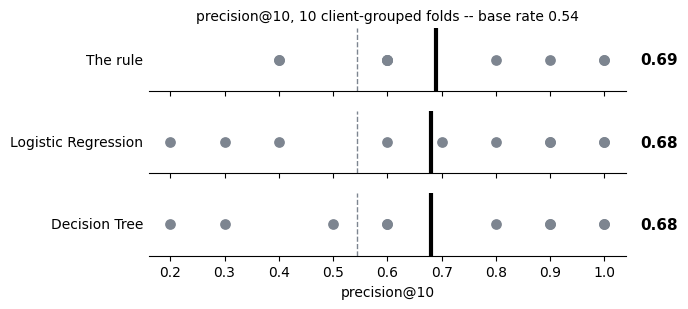


Shallow decision tree (max_depth=3), read top to bottom:
|--- content_age_days_at_decision <= 269.50
|   |--- prev_30_ctr <= 0.00
|   |   |--- prev_30_avg_position <= 48.40
|   |   |   |--- class: 1
|   |   |--- prev_30_avg_position >  48.40
|   |   |   |--- class: 0
|   |--- prev_30_ctr >  0.00
|   |   |--- prev_30_ctr <= 0.01
|   |   |   |--- class: 1
|   |   |--- prev_30_ctr >  0.01
|   |   |   |--- class: 0
|--- content_age_days_at_decision >  269.50
|   |--- prev_30_avg_position <= 35.40
|   |   |--- prev_30_clicks <= 3.50
|   |   |   |--- class: 1
|   |   |--- prev_30_clicks >  3.50
|   |   |   |--- class: 0
|   |--- prev_30_avg_position >  35.40
|   |   |--- search_volume <= 125.00
|   |   |   |--- class: 0
|   |   |--- search_volume >  125.00
|   |   |   |--- class: 0


Logistic regression -- top 12 coefficients by magnitude (positive = pushes toward is_declining):
content_age_days_at_decision      -0.569
main_intent_NA                    -0.565
char_count_tier_<8000          

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

K_CV = 10  # precision@K used for every fold below -- one documented choice, easy to change

K_fold = 10
gkf = GroupKFold(n_splits=K_fold)
fold_results = {"baseline_CTR_BELOW_POSITION_PEERS": [], "logistic_regression": [], "decision_tree_depth3": []}

for fold_i, (tr_idx, te_idx) in enumerate(gkf.split(df, y, groups), start=1):
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    # ---- The rule, refit this fold: tier means learned from TRAIN-eligible rows only ----
    fold_base = baseline_df.copy()
    tr_eligible_rows = fold_base.iloc[tr_idx][eligible.iloc[tr_idx]]
    fold_tier_means = tr_eligible_rows.groupby("position_tier", observed=True)["prev_30_ctr"].mean()

    fold_base["expected_ctr_for_tier"] = fold_base["position_tier"].map(fold_tier_means.to_dict()).astype(float)
    fold_base["ctr_gap"] = (fold_base["expected_ctr_for_tier"] - fold_base["prev_30_ctr"]).fillna(0)
    fold_flagged = eligible & (fold_base["prev_30_ctr"] == 0)
    fold_base["fold_score"] = np.where(fold_flagged, fold_base["prev_30_impressions"] * fold_base["ctr_gap"], 0.0)

    fold_results["baseline_CTR_BELOW_POSITION_PEERS"].append(
        precision_at_k(fold_base["fold_score"].iloc[te_idx].values, y_te, K_CV)
    )

    # ---- Both models, refit fresh this fold (clone() -- no state carried over between folds) ----
    lr_fold = clone(lr_pipe)
    tree_fold = clone(tree_pipe)
    lr_fold.fit(df.iloc[tr_idx], y_tr)
    tree_fold.fit(df.iloc[tr_idx], y_tr)

    fold_results["logistic_regression"].append(
        precision_at_k(lr_fold.predict_proba(df.iloc[te_idx])[:, 1], y_te, K_CV)
    )
    fold_results["decision_tree_depth3"].append(
        precision_at_k(tree_fold.predict_proba(df.iloc[te_idx])[:, 1], y_te, K_CV)
    )

fold_table = pd.DataFrame(fold_results)
fold_table.index = [f"fold_{i}" for i in range(1, K_fold + 1)]

# ---- The dot plot: each model's 5 fold scores, the overall base rate, each model's fold mean ----
overall_base_rate = y.mean()
model_order = ["baseline_CTR_BELOW_POSITION_PEERS", "logistic_regression", "decision_tree_depth3"]
model_labels = ["The rule", "Logistic Regression", "Decision Tree"]

fig, axes = plt.subplots(len(model_order), 1, figsize=(7, 3.2), sharex=True)
for ax, key, label in zip(axes, model_order, model_labels):
    scores = fold_results[key]
    mean_score = float(np.mean(scores))
    ax.scatter(scores, [0] * len(scores), s=45, color="#7d8590", zorder=3)
    ax.axvline(overall_base_rate, color="#7d8590", linestyle="--", linewidth=1, zorder=1)
    ax.axvline(mean_score, color="black", linewidth=3, zorder=2)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
    ax.text(1.03, 0, f"{mean_score:.2f}", transform=ax.get_yaxis_transform(),
            va="center", fontsize=11, fontweight="bold")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

axes[0].set_title(f"precision@{K_CV}, {K_fold} client-grouped folds -- base rate {overall_base_rate:.2f}", fontsize=10)
axes[-1].set_xlabel(f"precision@{K_CV}")
plt.tight_layout()
plt.show()

# ---- The shallow tree, printed in full (the single-split model fit in the previous cell) ----
feat_names_tree = numeric_cols + list(
    tree_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
)
print("\nShallow decision tree (max_depth=3), read top to bottom:")
print(export_text(tree_pipe.named_steps["clf"], feature_names=feat_names_tree))

# ---- Logistic regression coefficients (the single-split model fit in the previous cell) ----
feat_names_lr = numeric_cols + list(
    lr_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
)
lr_coefs = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=feat_names_lr).sort_values(key=abs, ascending=False)
print("\nLogistic regression -- top 12 coefficients by magnitude (positive = pushes toward is_declining):")
print(lr_coefs.head(12).round(3))

### 3b. Five-fold validation, with precision, recall and f1

We see that rule is actually good at metrics of precision@k and precision, but performs poorly with recall and f1. Hence it is great for selecting which contents to review. It even performs slightly better than the models.

But regarding the prediction, the models are definitely better.

Taking a look at the k-fold-cv-estimated precision, recall and f1, we see that decision tree performs better than a logistic regression.




In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

classification_fold_results = {
    "baseline_CTR_BELOW_POSITION_PEERS": {"precision": [], "recall": [], "f1": []},
    "logistic_regression": {"precision": [], "recall": [], "f1": []},
    "decision_tree_depth3": {"precision": [], "recall": [], "f1": []},
}

for fold_i, (tr_idx, te_idx) in enumerate(gkf.split(df, y, groups), start=1):
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    # ---- The rule: its own binary decision IS "flagged" -- no threshold to pick ----
    fold_base = baseline_df.copy()
    tr_eligible_rows = fold_base.iloc[tr_idx][eligible.iloc[tr_idx]]
    fold_tier_means = tr_eligible_rows.groupby("position_tier", observed=True)["prev_30_ctr"].mean()
    fold_base["expected_ctr_for_tier"] = fold_base["position_tier"].map(fold_tier_means.to_dict()).astype(float)
    fold_flagged = eligible & (fold_base["prev_30_ctr"] == 0)
    baseline_pred = fold_flagged.iloc[te_idx].astype(int).values

    # ---- Both models: refit fresh this fold, predict at the default 0.5 threshold ----
    lr_fold = clone(lr_pipe)
    tree_fold = clone(tree_pipe)
    lr_fold.fit(df.iloc[tr_idx], y_tr)
    tree_fold.fit(df.iloc[tr_idx], y_tr)
    lr_pred = lr_fold.predict(df.iloc[te_idx])
    tree_pred = tree_fold.predict(df.iloc[te_idx])

    for key, pred in [
        ("baseline_CTR_BELOW_POSITION_PEERS", baseline_pred),
        ("logistic_regression", lr_pred),
        ("decision_tree_depth3", tree_pred),
    ]:
        classification_fold_results[key]["precision"].append(precision_score(y_te, pred, zero_division=0))
        classification_fold_results[key]["recall"].append(recall_score(y_te, pred, zero_division=0))

# ---- One summary table: mean precision/recall/f1 per model, all folds ----
summary_rows = []
for key, vals in classification_fold_results.items():
    summary_rows.append({
        "model": key,
        "precision": np.mean(vals["precision"]),
        "recall": np.mean(vals["recall"]),
        "f1": 2 * (np.mean(vals["precision"]) * np.mean(vals["recall"])) / (np.mean(vals["precision"]) + np.mean(vals["recall"])),
    })
classification_summary = pd.DataFrame(summary_rows).set_index("model").round(3)
classification_summary

,precision,recall,f1
model,,,
baseline_CTR_BELOW_POSITION_PEERS,0.627,0.111,0.189
logistic_regression,0.619,0.596,0.607
decision_tree_depth3,0.603,0.766,0.675


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

**The headline finding: both models massively over-predict the positive class at the default 0.5
threshold.** LR calls 73.6% of the test set "declining"; the tree calls 81.3%; only 47.3% actually
are. That single fact is most of the story -- it's why both models generate so many false
positives, and it's *exactly* why section 3's precision@K table (0.50-0.80 for most K) looks so
much better than section 3b's fixed-threshold precision/recall/F1 (0.60-0.63 precision) for the
same two models.

**LR's real top 10 (precision@10 = 0.20, so 8 of these are wrong) shares one specific profile**:
huge `prev_30_impressions` (35,000-268,000), near-zero `prev_30_ctr`, decent position (3-10). LR
has essentially learned "big page + near-zero clicks = certain decline" -- directionally sensible
given its coefficients (`prev_30_clicks` -0.518, `prev_30_impressions` +0.327), but it appears to
over-extrapolate that pattern at the extreme end of the impression scale, a common linear-model
failure mode. Eight of these ten huge, near-zero-CTR pages turned out to be perfectly stable.

**The two models' false positives overlap heavily** (2,351 shared -- 94.3% of LR's, 81.1% of the
tree's), consistent with both simply flagging most things positive rather than making two
genuinely different kinds of mistakes.

**LR's false negatives skew toward lower-traffic pages** (hundreds to low-thousands of impressions)
that declined anyway -- consistent with `prev_30_impressions`' positive coefficient systematically
pulling smaller pages' predicted probability down, regardless of their other risk factors.

**Practical read:** if this tool is used as a ranked queue a reviewer works down top-to-bottom
(which is how w04's rule and section 3's precision@K both frame it), the threshold-driven
over-prediction above matters less than it looks -- a reviewer never sees the 73%/81% "positive"
calls, only the ranking. If it's ever used as a fixed yes/no classifier instead, this over-
prediction is a real problem worth fixing (recalibrating the threshold, or reporting probabilities
directly) before trusting it that way.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.metrics import confusion_matrix

lr_pred = lr_pipe.predict(X_test)
tree_pred = tree_pipe.predict(X_test)

print("Logistic Regression confusion matrix (rows=true, cols=predicted):")
print(confusion_matrix(y_test, lr_pred))
print(f"LR predicts \'declining\' for {lr_pred.mean():.1%} of the test set (actual rate: {y_test.mean():.1%})")

print("\nDecision Tree confusion matrix:")
print(confusion_matrix(y_test, tree_pred))
print(f"Tree predicts \'declining\' for {tree_pred.mean():.1%} of the test set (actual rate: {y_test.mean():.1%})")

# ---- content_hash_id for readable examples below (excluded from df/X_test on purpose -- it's an ID, not a feature) ----
content_ids_test = features.iloc[test_idx]["content_hash_id"].values

test_view = X_test.copy()
test_view["content_hash_id"] = content_ids_test
test_view["is_declining"] = y_test.values
test_view["lr_pred"] = lr_pred
test_view["tree_pred"] = tree_pred

# ---- How much does prev_30_ctr == 0 actually explain the false positives? ----
lr_fp = test_view[(test_view["lr_pred"] == 1) & (test_view["is_declining"] == 0)]
tree_fp = test_view[(test_view["tree_pred"] == 1) & (test_view["is_declining"] == 0)]

zero_click_share = (test_view["prev_30_ctr"] == 0).mean()
zero_click_decline = test_view.loc[test_view["prev_30_ctr"] == 0, "is_declining"].mean()
print(f"\nprev_30_ctr == 0: {zero_click_share:.1%} of the test set; decline rate there is "
      f"{zero_click_decline:.3f} vs {y_test.mean():.3f} overall -- barely any lift.")
print(f"Share of LR\'s false positives with prev_30_ctr == 0:   {(lr_fp['prev_30_ctr']==0).mean():.1%}  (n={len(lr_fp)})")
print(f"Share of tree\'s false positives with prev_30_ctr == 0: {(tree_fp['prev_30_ctr']==0).mean():.1%}  (n={len(tree_fp)})")

shared_fp = set(lr_fp.index) & set(tree_fp.index)
print(f"\nFalse positives BOTH models make: {len(shared_fp):,} "
      f"({len(shared_fp)/len(lr_fp):.1%} of LR\'s, {len(shared_fp)/len(tree_fp):.1%} of tree\'s)")

# ---- LR's actual top 10 -- the precision@10=0.20 result, row by row ----
test_view["lr_proba"] = lr_pipe.predict_proba(X_test)[:, 1]
cols_show = ["content_hash_id", "is_declining", "lr_pred", "tree_pred", "prev_30_impressions",
             "prev_30_avg_position", "prev_30_ctr", "prev_30_clicks",
             "content_age_days_at_decision", "days_since_last_update_at_decision", "content_type"]
top10_lr = test_view.sort_values("lr_proba", ascending=False).head(10)
print("\nLR\'s real top 10 by predicted probability:")
print(top10_lr[["lr_proba"] + cols_show].to_string())

# ---- LR's false negatives: what do the missed declines look like? ----
lr_fn = test_view[(test_view["lr_pred"] == 0) & (test_view["is_declining"] == 1)]
print(f"\nLR false negatives (n={len(lr_fn)}) -- a sample:")
print(lr_fn[cols_show].head(5).to_string())


Logistic Regression confusion matrix (rows=true, cols=predicted):
[[1335 2493]
 [ 585 2848]]
LR predicts 'declining' for 73.6% of the test set (actual rate: 47.3%)

Decision Tree confusion matrix:
[[ 930 2898]
 [ 426 3007]]
Tree predicts 'declining' for 81.3% of the test set (actual rate: 47.3%)

prev_30_ctr == 0: 48.3% of the test set; decline rate there is 0.483 vs 0.473 overall -- barely any lift.
Share of LR's false positives with prev_30_ctr == 0:   54.8%  (n=2493)
Share of tree's false positives with prev_30_ctr == 0: 53.1%  (n=2898)

False positives BOTH models make: 2,351 (94.3% of LR's, 81.1% of tree's)

LR's real top 10 by predicted probability:
       lr_proba           content_hash_id  is_declining  lr_pred  tree_pred  prev_30_impressions  prev_30_avg_position  prev_30_ctr  prev_30_clicks  content_age_days_at_decision  days_since_last_update_at_decision     content_type
93926  1.000000  content_99fc6465edb0e52c             1        1          1             267960.0         

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.